### Funciones básicas

In [8]:
import numpy as np
import random
from sklearn.metrics import adjusted_rand_score
import pandas as pd


# =========================
# ЧТЕНИЕ ДАННЫХ
# =========================
# N — número de datos (cantidad de puntos)
# K — número de atributos (dimensión de cada punto)
# M — número de clusters (grupos)

# N — количество объектов (размер набора данных)
# K — размерность данных (число признаков у каждой точки)
# M — число кластеров, на которые делим данные
from sklearn.datasets import make_blobs

def leer_datos():
    # генерируем синтетические данные (кластеризованные)
    X, y_true = make_blobs(
        n_samples=100,   # число точек (N)
        centers=3,       # число кластеров (M)
        n_features=2,    # размерность (K)
        cluster_std=0.3, # разброс (малый → легко кластеризуется)
        random_state=42
    )
    
    # N — число объектов
    N = X.shape[0]
    
    # K — число признаков
    K = X.shape[1]
    
    # M — число кластеров
    M = 3
    
    return np.array(X), N, K, M, y_true

In [15]:

# =========================
# ВЫЧИСЛЕНИЕ ЦЕНТРОВ
# =========================
# вычисляет центры кластеров на основе разбиения P и данных X
def calcular_medoides(P, X, M):
    """
    P - разбиение (вектор кластеров)
    X - данные
    M - число кластеров
    
    Возвращает medoids (представители кластеров из X)
    """
    
    K = X.shape[1]
    medoids = np.zeros((M, K))
    
    for j in range(M):
        # выбираем точки кластера j
        puntos = X[P == j]
        
        if len(puntos) > 0:
            # считаем сумму расстояний для каждой точки
            mejor_punto = None
            mejor_dist = float('inf')
            
            for p in puntos:
                suma = 0.0
                
                for q in puntos:
                    suma += np.linalg.norm(p - q)
                
                # ищем точку с минимальной суммой расстояний
                if suma < mejor_dist:
                    mejor_dist = suma
                    mejor_punto = p
            
            medoids[j] = mejor_punto
        
        else:
            # если кластер пуст — случайная точка
            medoids[j] = X[random.randint(0, len(X)-1)]
    
    return medoids


In [16]:

# =========================
# FITNESS (ЦЕЛЕВАЯ ФУНКЦИЯ)
# =========================

def fitness(P, X, M):
    # получаем центр каждого кластера
    medoids = calcular_medoides(P, X, M)
    
    total = 0.0
    # считаем сумму расстояний` от каждой точки до центра её кластера`
    for i in range(len(X)):
        c = medoids[P[i]]
        total += np.linalg.norm(X[i] - c)**2
    
    return total

In [17]:

# =========================
# ИНИЦИАЛИЗАЦИЯ ПОПУЛЯЦИИ
# =========================
def inicializar_poblacion(popSize, N, M):
    poblacion = []
    # Создаем количество возможных решений, равное размеру популяции
    for _ in range(popSize):
        # случайное разбиение, где M — число кластеров, а N — количество точек
        individuo = np.random.randint(0, M, size=N)
        # Добавляем созданное решение в популяцию
        poblacion.append(individuo)
    
    return np.array(poblacion)
# def inicializar_poblacion(popSize, N, M):
#     poblacion = []
#     # Создаем количество возможных решений, равное размеру популяции
#     for _ in range(popSize):
    #     valido = False
        
    #     # флаг, который проверяет, что решение содержит все кластеры
    #     # indicador que verifica que la solución contiene todos los clusters
        
    #     while not valido:
    #         individuo = np.random.randint(0, M, size=N)
            
    #         # генерируем случайное решение длины N со значениями от 0 до M-1
    #         # generamos una solución aleatoria de longitud N con valores entre 0 y M-1
            
    #         if len(np.unique(individuo)) == M:
    #             valido = True
                
    #             # проверяем, что ни один кластер не пустой
    #             # verificamos que ningún cluster esté vacío
        
    #     poblacion.append(individuo)
        
    #     # добавляем валидное решение в популяцию
    #     # añadimos la solución válida a la población
    
    # return np.array(poblacion)


In [18]:
# =========================
# ОЦЕНКА ПОПУЛЯЦИИ
# =========================

def evaluar_poblacion(poblacion, X, M):
    fitness_vals = []
    # оцениваем каждое разбиение в популяции
    for ind in poblacion:
        fitness_vals.append(fitness(ind, X, M))
    
    return np.array(fitness_vals)

In [19]:
# =========================
# ОБУЧЕНИЕ РАСПРЕДЕЛЕНИЯ
# =========================

def aprender_distribucion(mejores, N, M):
    """
    mejores: лучшие решения
    возвращает P(i,j) — вероятность, что элемент i в кластере j
    """
    # N - количество точек
    # M - число кластеров
    distribucion = np.zeros((N, M))
    # Создаём матрицу вероятностей, где distribucion[i, j] — это вероятность того, что точка i принадлежит кластеру j. 
    # Изначально она заполнена нулями.
    for i in range(N):
    # в каком кластере чаще всего находится точка i
        for ind in mejores:
            distribucion[i, ind[i]] += 1
        
        distribucion[i] /= len(mejores)
    
    return distribucion

In [20]:
# =========================
# ГЕНЕРАЦИЯ НОВОЙ ПОПУЛЯЦИИ
# =========================

def muestrear(distribucion, popSize, N, M):
    # distribucion — матрица вероятностей размера (N x M)
    # distribucion[i][j] = вероятность того, что точка i попадёт в кластер j

    nueva_poblacion = []  # сюда будем сохранять новые решения

    # создаём popSize новых решений (индивидов)
    for _ in range(popSize):
        
        # создаём пустой индивид (разбиение)
        # длина N — по одному кластеру для каждой точки
        individuo = np.zeros(N, dtype=int)
        
        # для каждой точки i выбираем кластер
        for i in range(N):
            
            # np.random.choice выбирает случайное значение из {0,...,M-1}
            # но НЕ равновероятно, а по заданным вероятностям distribucion[i]
            
            # distribucion[i] — это, например:
            # [0.7, 0.2, 0.1]
            # значит:
            # 70% → кластер 0
            # 20% → кластер 1
            # 10% → кластер 2
            
            individuo[i] = np.random.choice(range(M), p=distribucion[i])
        
        # добавляем готовое решение в популяцию
        nueva_poblacion.append(individuo)
    
    # преобразуем список в numpy-массив
    return np.array(nueva_poblacion)

In [45]:
# =========================
# ОСНОВНОЙ АЛГОРИТМ EDA
# =========================
# 🔹 fichero 👉 путь к файлу с данными
# содержит точки (dataset)
# пример: "test.txt"
# 🔹 popSize
# 👉 размер популяции
# сколько решений (разбиений) храним на каждой итерации
# больше → лучше поиск, но медленнее
# 🔹 numPadres
# 👉 число лучших решений для обучения
# сколько "лучших" используем, чтобы построить распределение
# меньше → сильнее давление отбора
# больше → больше разнообразия
# 🔹 iteraciones
# 👉 число итераций алгоритма
# сколько раз повторяем цикл EDA
# больше → лучше результат, но дольше
def EDA_clustering( popSize=50, numPadres=10, iteraciones=50, save_log=False, seed=0):
    
    # читаем данные
    X, N, K, M, y_true = leer_datos()
    
    # начальная популяция
    poblacion = inicializar_poblacion(popSize, N, M)
    # лучшее разбиение (индивид)
    mejor_global = None
    # лучшее значение лучшего разбиения
    # float('inf') — начальное значение, так как задача — минимизация:
    # мы ищем разбиение, минимизирующее сумму квадратов расстояний от точек до центров кластеров
    mejor_fitness = float('inf')
    log_media = []
    log_mejor = []    
    for it in range(iteraciones):
        
        # оцениваем
        # ппосчитаем fitness для каждого решения
        fitness_vals = evaluar_poblacion(poblacion, X, M)

        # сортируем
        orden = np.argsort(fitness_vals)
        poblacion = poblacion[orden]
        # после сортировки fitness_vals[0] — это лучший
        # fitness в текущей популяции
        # fitness_vals[-1] → худший
        fitness_vals = fitness_vals[orden]
        # мы минимизируем fitness
        # меньше = лучше
        # argsort сортирует по возрастанию
        
        # обновляем лучшее
        if fitness_vals[0] < mejor_fitness:
            mejor_fitness = fitness_vals[0]
            mejor_global = poblacion[0].copy()
        
        # выбираем лучших
        mejores = poblacion[:numPadres]
        
        # учим распределение
        distribucion = aprender_distribucion(mejores, N, M)
        
        # генерируем новую популяцию
        poblacion = muestrear(distribucion, popSize, N, M)
         
        print(f"Iter {it}: mejor = {fitness_vals[0]:.4f}, media = {np.mean(fitness_vals):.4f}")
        log_media.append(np.mean(fitness_vals))
        log_mejor.append(mejor_fitness)
    if save_log:
        np.savetxt(f"log_media_seed_{seed}.txt", log_media)
        np.savetxt(f"log_mejor_seed_{seed}.txt", log_mejor)
    print("\n=== RESULTADO FINAL ===")
    print("Mejor fitness:", mejor_fitness)
    print("Mejor partición:", mejor_global)
    return mejor_fitness, mejor_global, y_true

### El primer inicio

In [22]:
# =========================
# ЗАПУСК
# =========================
np.random.seed(975376)
mejor_fitness, mejor_global, y_true= EDA_clustering( 100, 20, 50)


Iter 0: mejor = 8990.6975, media = 9933.9823
Iter 1: mejor = 8882.8082, media = 9887.1007
Iter 2: mejor = 9192.8384, media = 9886.3820
Iter 3: mejor = 8554.3755, media = 9528.8822
Iter 4: mejor = 7451.2762, media = 9111.0858
Iter 5: mejor = 6400.5771, media = 8315.5065
Iter 6: mejor = 5426.8801, media = 7196.4664
Iter 7: mejor = 4710.9058, media = 6300.5671
Iter 8: mejor = 3887.3419, media = 5249.8093
Iter 9: mejor = 2665.6146, media = 4288.8633
Iter 10: mejor = 1471.4314, media = 3470.3684
Iter 11: mejor = 1402.1450, media = 2497.6064
Iter 12: mejor = 803.7761, media = 1782.4985
Iter 13: mejor = 701.3969, media = 1223.3819
Iter 14: mejor = 603.4587, media = 887.7474
Iter 15: mejor = 409.9749, media = 642.6046
Iter 16: mejor = 409.9749, media = 484.0668
Iter 17: mejor = 409.9749, media = 409.9749
Iter 18: mejor = 409.9749, media = 409.9749
Iter 19: mejor = 409.9749, media = 409.9749
Iter 20: mejor = 409.9749, media = 409.9749
Iter 21: mejor = 409.9749, media = 409.9749
Iter 22: mejor =

In [23]:
from sklearn.metrics import adjusted_rand_score

print(adjusted_rand_score(y_true, mejor_global))

0.9096037247548134


### Con diferentes seeds

In [27]:

# список сидов
seeds = [314, 2718, 4096, 5501, 6789, 8081,
               9097, 11113, 12347, 14591, 16763, 18973]
i=9
for seed in seeds:
    # фиксируем случайность
    np.random.seed(seed)
    random.seed(seed)
    
    # запуск алгоритма
    mejor_fitness, mejor_global, y_true = EDA_clustering(100, 20, 30)
    
    # считаем ARI
    ari = adjusted_rand_score(y_true, mejor_global)
    
    print(f"Seed {seed} → ARI = {ari}")
    
    # сохраняем предсказания
    np.savetxt(f"{i}pred_seed_{seed}.txt", mejor_global, fmt='%d')
    
    # сохраняем истинные метки
    np.savetxt(f"{i}true_seed_{seed}.txt", y_true, fmt='%d')
    
    # сохраняем метрику
    with open(f"{i}score_seed_{seed}.txt", "w") as f:
        f.write(str(ari))
    i+=1

Iter 0: mejor = 8751.5262, media = 9896.1626
Iter 1: mejor = 9143.2572, media = 9850.6390
Iter 2: mejor = 9206.7084, media = 9926.7835
Iter 3: mejor = 8973.3595, media = 9899.0521
Iter 4: mejor = 8431.8339, media = 9837.3955
Iter 5: mejor = 8421.9474, media = 9786.4934
Iter 6: mejor = 7812.9717, media = 9319.9996
Iter 7: mejor = 6705.6698, media = 8416.0224
Iter 8: mejor = 5606.7155, media = 7567.7845
Iter 9: mejor = 5074.6138, media = 6622.6373
Iter 10: mejor = 4288.9605, media = 5800.7779
Iter 11: mejor = 3835.7133, media = 4883.9058
Iter 12: mejor = 3468.2838, media = 4244.9941
Iter 13: mejor = 3084.8629, media = 3788.3267
Iter 14: mejor = 2974.7433, media = 3441.4445
Iter 15: mejor = 2528.7077, media = 3131.9769
Iter 16: mejor = 2295.9377, media = 2825.9899
Iter 17: mejor = 2039.1830, media = 2558.2118
Iter 18: mejor = 2127.7049, media = 2296.2205
Iter 19: mejor = 2039.1830, media = 2152.8393
Iter 20: mejor = 2039.1830, media = 2039.1830
Iter 21: mejor = 2039.1830, media = 2039.183

In [ ]:
import numpy as np
import pandas as pd

# список всех seed-ов
seeds = [42, 123, 999, 975376, 7839, 2034, 3787, 12027, 20628, 1029,
       2718, 4096, 5501, 6789, 8081, 9097, 11113, 12347, 14591, 16763, 18973]

# собираем результаты
results = []

for i, seed in enumerate(seeds):
    with open(f"{i}score_seed_{seed}.txt", "r") as f:
        score = float(f.read())
    
    results.append({
        "run": i,
        "seed": seed,
        "ARI": score
    })

# создаем таблицу
df = pd.DataFrame(results)

print(df)

    run    seed       ARI
0     0      42  0.797770
1     1     123  0.826687
2     2     999  0.666182
3     3  975376  0.909604
4     4    7839  0.747665
5     5    2034  0.697416
6     6    3787  0.746248
7     7   12027  0.776885
8     8   20628  0.457136
9     9    1029  0.680375
10   10    2718  0.751311
11   11    4096  0.743913
12   12    5501  0.825548
13   13    6789  0.940300
14   14    8081  0.776885
15   15    9097  0.661627
16   16   11113  0.727651
17   17   12347  0.729743
18   18   14591  0.939401
19   19   16763  0.776956
20   20   18973  0.685336


In [34]:
summary = df["ARI"].agg(["mean", "min", "max", "std"])
print(summary)

mean    0.755459
min     0.457136
max     0.940300
std     0.106382
Name: ARI, dtype: float64


### Top 3 peores

In [ ]:
выбрать топ 3 худшиз и запустить на больших иттерациях и построить графики

In [36]:
worst_3 = df.nsmallest(3, "ARI")

print(worst_3)

    run   seed       ARI
8     8  20628  0.457136
15   15   9097  0.661627
2     2    999  0.666182


In [46]:
worst_seeds = worst_3["seed"].tolist()

for seed in worst_seeds:
    np.random.seed(seed)
    random.seed(seed)
    
    EDA_clustering(
        popSize=100,
        numPadres=20,
        iteraciones=50,
        save_log=True,
        seed=seed
    )

Iter 0: mejor = 9004.8834, media = 9896.0383
Iter 1: mejor = 8903.6678, media = 9911.3883
Iter 2: mejor = 9177.8582, media = 9908.5556
Iter 3: mejor = 9033.2453, media = 9890.5481
Iter 4: mejor = 8736.3443, media = 9912.8211
Iter 5: mejor = 8386.2877, media = 9830.3342
Iter 6: mejor = 8724.9191, media = 9844.7254
Iter 7: mejor = 8586.3664, media = 9767.3188
Iter 8: mejor = 8071.1189, media = 9377.9233
Iter 9: mejor = 6936.1557, media = 8680.9330
Iter 10: mejor = 6113.9422, media = 7770.7145
Iter 11: mejor = 5036.4073, media = 6850.0608
Iter 12: mejor = 4751.1437, media = 6108.1358
Iter 13: mejor = 4327.6562, media = 5223.8179
Iter 14: mejor = 3803.0877, media = 4640.7187
Iter 15: mejor = 3649.8482, media = 4253.5781
Iter 16: mejor = 3466.2281, media = 3876.3674
Iter 17: mejor = 3286.6786, media = 3629.8107
Iter 18: mejor = 3168.2364, media = 3426.8850
Iter 19: mejor = 3168.2364, media = 3257.3825
Iter 20: mejor = 3168.2364, media = 3168.2364
Iter 21: mejor = 3168.2364, media = 3168.236

In [40]:
! pip install matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl (1.6 MB)


You should consider upgrading via the 'C:\Users\Евгения\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [42]:
import matplotlib.pyplot as plt

In [48]:
import numpy as np

logs = {}

for seed in worst_seeds:
    media = np.loadtxt(f"log_media_seed_{seed}.txt")
    mejor = np.loadtxt(f"log_mejor_seed_{seed}.txt")
    
    logs[seed] = {
        "media": media,
        "mejor": mejor
    }

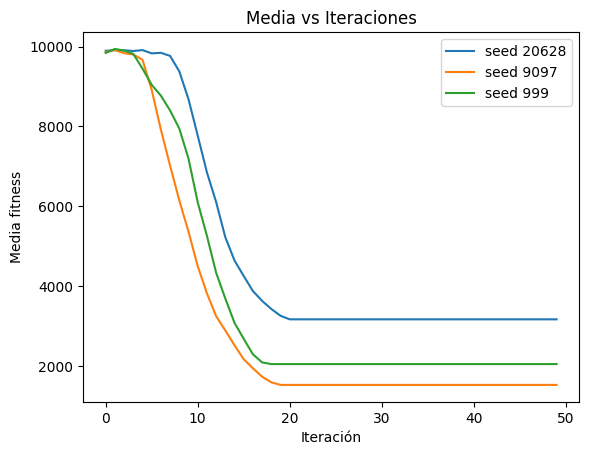

In [49]:
plt.figure()

for seed in worst_seeds:
    plt.plot(logs[seed]["media"], label=f"seed {seed}")

plt.title("Media vs Iteraciones")
plt.xlabel("Iteración")
plt.ylabel("Media fitness")
plt.legend()
plt.show()

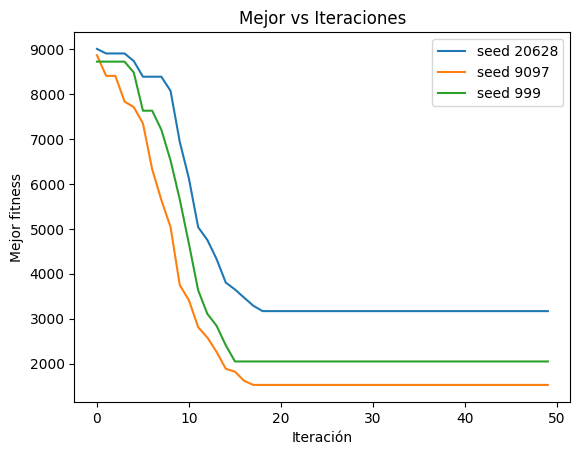

In [50]:
plt.figure()

for seed in worst_seeds:
    plt.plot(logs[seed]["mejor"], label=f"seed {seed}")

plt.title("Mejor vs Iteraciones")
plt.xlabel("Iteración")
plt.ylabel("Mejor fitness")
plt.legend()
plt.show()

### Combinacónes de padres y populacíones

In [3]:
configs = [
    (50, 10),
    (50, 20),
    (50, 30),
    (100, 10),
    (100, 20),
    (100, 30),
    (150, 20),
    (150, 30),
    (200, 20),
    (200, 40),
]

In [53]:
worst_seed

np.float64(20628.0)

In [ ]:

results = []
worst_seed = worst_3.iloc[0]["seed"].astype(int)
for i, (popSize, numPadres) in enumerate(configs):
    
    np.random.seed(worst_seed)
    random.seed(worst_seed)
    
    mejor_fitness, mejor_global, y_true = EDA_clustering(
        popSize=popSize,
        numPadres=numPadres,
        iteraciones=50,
        save_log=True,
        seed=f"{worst_seed}_exp{i}"
    )
    
    ari = adjusted_rand_score(y_true, mejor_global)
    
    results.append({
        "exp": i,
        "popSize": popSize,
        "numPadres": numPadres,
        "ARI": ari
    })
    
    print(f"Exp {i}: pop={popSize}, padres={numPadres} → ARI={ari:.4f}")

NameError: name 'worst_3' is not defined

In [4]:
df_exp = pd.DataFrame(results)
print(df_exp)

NameError: name 'pd' is not defined

In [56]:
df_exp.to_csv("experimentos_worst_seed.csv", index=False)

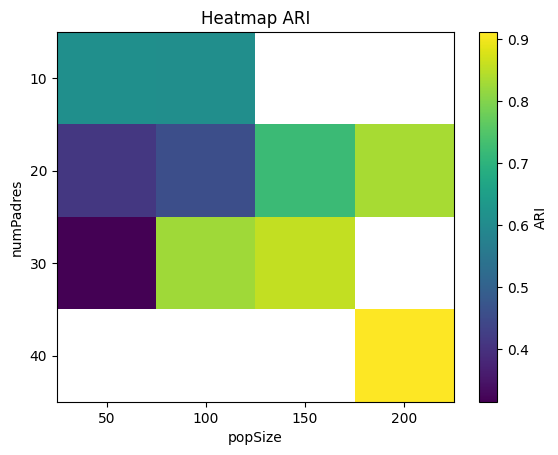

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# преобразуем в матрицу
pivot = df_exp.pivot(index="numPadres", columns="popSize", values="ARI")

plt.figure()

# рисуем heatmap
plt.imshow(pivot, aspect='auto')

# подписи осей
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("popSize")
plt.ylabel("numPadres")
plt.title("Heatmap ARI")

# цветовая шкала
plt.colorbar(label="ARI")

plt.show()